In [1]:
# 01_eda.ipynb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


✅ Loaded 394 speaker samples from 110 meetings

📊 Label distribution:
role
other      232
junior      82
manager     80
Name: count, dtype: int64
💾 Saved label counts to reports/label_counts.csv

👥 Speakers per meeting: min=2, max=5, mean=3.6
💾 Saved speakers-per-meeting to reports/speakers_per_meeting.csv

📝 Avg text length: 15.4 words
📄 Wrote report to reports/eda_report.md


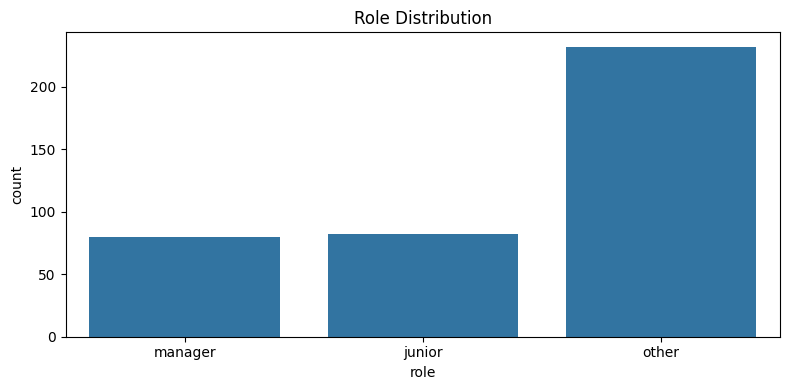

🖼️ Saved plot to reports/role_dist.png


In [5]:
# Upgraded EDA cell — safe + robust
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Config ---
INPUT_PATH = "data/labeled_roles.csv"
REPORT_DIR = Path("reports")
OUTPUT_REPORT = REPORT_DIR / "eda_report.md"
ROLE_COUNT_CSV = REPORT_DIR / "label_counts.csv"
SPEAKERS_PER_MEETING_CSV = REPORT_DIR / "speakers_per_meeting.csv"
PLOT_PATH = REPORT_DIR / "role_dist.png"

# --- Prepare output dir ---
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load (with check) ---
if not Path(INPUT_PATH).exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_PATH}")

df = pd.read_csv(INPUT_PATH)
required_cols = {"meeting_id", "speaker_id", "full_text", "role"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in CSV: {sorted(missing)}")

print(f"✅ Loaded {len(df)} speaker samples from {df.meeting_id.nunique()} meetings")

# --- Normalize role column (optional) ---
# Ensure consistent lowercase roles (you can remove this if you prefer original casing)
df['role'] = df['role'].astype(str).str.strip().str.lower()

# --- Label distribution ---
label_counts = df['role'].value_counts()
print("\n📊 Label distribution:")
print(label_counts)

# Save label counts to CSV for later use
label_counts.to_frame(name="count").to_csv(ROLE_COUNT_CSV, index=True)
print(f"💾 Saved label counts to {ROLE_COUNT_CSV}")

# --- Speakers per meeting ---
speakers_per_meeting = df.groupby('meeting_id')['speaker_id'].nunique()
print(f"\n👥 Speakers per meeting: min={speakers_per_meeting.min()}, max={speakers_per_meeting.max()}, mean={speakers_per_meeting.mean():.1f}")
speakers_per_meeting.to_csv(SPEAKERS_PER_MEETING_CSV, header=["num_speakers"])
print(f"💾 Saved speakers-per-meeting to {SPEAKERS_PER_MEETING_CSV}")

# --- Text length stats ---
df['text_len'] = df['full_text'].astype(str).str.len()
df['word_count'] = df['full_text'].astype(str).str.split().str.len()
print(f"\n📝 Avg text length: {df['word_count'].mean():.1f} words")

# --- Save simple report (markdown) ---
# Use to_markdown if tabulate is available, else fallback to to_string()
try:
    label_md = label_counts.to_markdown()
except Exception:
    label_md = label_counts.to_string()

report = f"""# EDA Report

- Total samples: {len(df)}
- Meetings: {df.meeting_id.nunique()}
- Label distribution:
{label_md}

- Speakers per meeting: {speakers_per_meeting.min()}–{speakers_per_meeting.max()}
- Avg words per speaker: {df['word_count'].mean():.1f}
"""

OUTPUT_REPORT.write_text(report, encoding="utf-8")
print(f"📄 Wrote report to {OUTPUT_REPORT}")

# --- Plot (safe path + style) ---
plt.figure(figsize=(8,4))
# choose order from observed roles; fall back to common order
desired_order = ['manager', 'junior', 'other']
order = [r for r in desired_order if r in label_counts.index] + \
        [r for r in label_counts.index if r not in desired_order]
sns.countplot(data=df, x='role', order=order)
plt.title("Role Distribution")
plt.tight_layout()
plt.savefig(PLOT_PATH, bbox_inches='tight')
plt.show()
print(f"🖼️ Saved plot to {PLOT_PATH}")
